Phase 1 - Understanding the Dataset

In [4]:
import sys
print(sys.executable)

d:\Projects\CRIM\backend\venv\Scripts\python.exe


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../notebooks/data/telco_churn.csv')

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 21)

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

In [7]:
# TotalCharges is string, convert to number
# errors='coerce' means if it finds something that can't be converted, make it NaN instead of crashing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many NaN values appeared after conversion
print("TotalCharges nulls after fix:", df['TotalCharges'].isnull().sum())

# Fill those nulls with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Quick stats on numerical columns
df.describe()

TotalCharges nulls after fix: 11


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


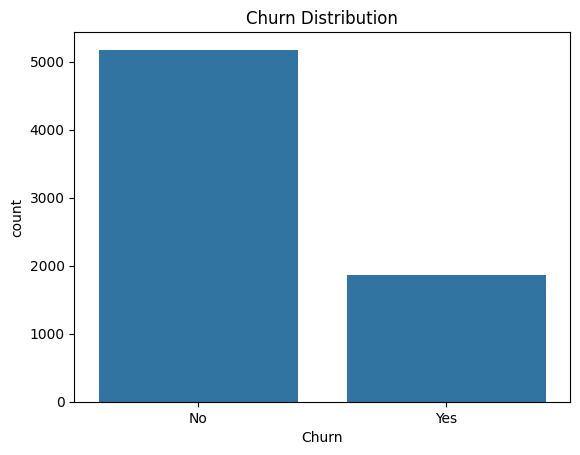

Churn Rate: 26.54 %


In [8]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

print("Churn Rate:", round(df['Churn'].value_counts(normalize=True)['Yes'] * 100, 2), "%")

Phase 2 - Preprocessing + Model Training

In [9]:
# Drop customerID - just an identifier, has no predictive value
# Drop the 11 rows where TotalCharges was null
df = df.drop(columns=['customerID'])
df = df.dropna(subset=['TotalCharges'])

# Convert Churn from Yes/No to 1/0 (Label Encoding)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Get all columns that are still text (object type)
categorical_cols = df.select_dtypes(include='str').columns.tolist()
print("Columns to encode:", categorical_cols)

# One Hot Encoding - converting each text column into relevant multiple 0/1 columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Churn value counts:", df['Churn'].value_counts())

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)
Churn value counts: Churn
0    5174
1    1869
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle

# Separate features (X) and target (y)
# X = everything except Churn column AND y = Churn column
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split data into training set and test set (80% goes to training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Model trained successfully!
Training samples: 5634
Testing samples: 1409


In [11]:
# Run predictions on the test set
y_pred = model.predict(X_test)

# Classification report shows precision, recall, f1-score per class
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.66      0.45      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
[[951  85]
 [205 168]]


In [12]:
# Save the trained model as a .pkl file for FASTAPI's usage later
with open('../backend/models/churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the column names (needed in backend)
# so preprocessing produces columns in the exact same order the model expects
feature_columns = X.columns.tolist()
with open('../backend/models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Model saved successfully!")
print("Total features:", len(feature_columns))

Model saved successfully!
Total features: 30


Phase 3 - Improve Model Training

In [13]:
import sys
print(sys.executable)

d:\Projects\CRIM\backend\venv\Scripts\python.exe


In [14]:
# New imports for improved model
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [15]:
# Check the imbalance first
print("Before SMOTE:")
print("Non-churners (0):", sum(y_train == 0))
print("Churners (1):", sum(y_train == 1))
print(f"Ratio: {sum(y_train==0)/sum(y_train==1):.1f}:1")

# Apply SMOTE (creates synthetic churner examples so model learns them better)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Non-churners (0):", sum(y_train_balanced == 0))
print("Churners (1):", sum(y_train_balanced == 1))
print("Dataset is now balanced!")

Before SMOTE:
Non-churners (0): 4138
Churners (1): 1496
Ratio: 2.8:1

After SMOTE:
Non-churners (0): 4138
Churners (1): 4138
Dataset is now balanced!


In [16]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_balanced, y_train_balanced)

print("XGBoost training complete")

XGBoost training complete


Evaluate XGBoost vs old Random Forest (side by side)

In [17]:
# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("XGBoost + SMOTE Results")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBoost + SMOTE Results
              precision    recall  f1-score   support

    No Churn       0.88      0.83      0.85      1036
       Churn       0.59      0.67      0.63       373

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.80      1409

ROC-AUC Score: 0.8456


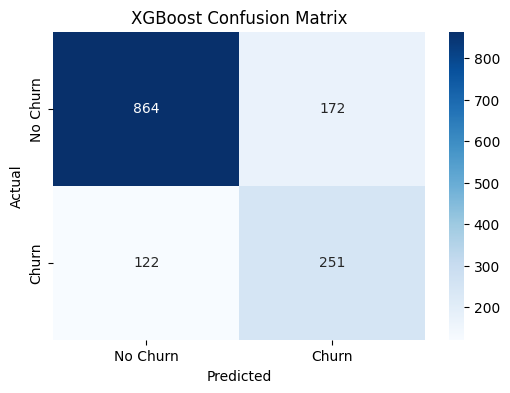

In [18]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [19]:
# Cross Validation (5-fold stratified)
# This splits data 5 different ways and trains/tests each time
# Interpretation: if F1 is consistently good across all 5 folds, the model is genuinely good
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_train_balanced, y_train_balanced,
                             cv=cv, scoring='f1')

print("Cross-Validation F1 Scores:", [round(s, 4) for s in cv_scores])
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("\nConsistent scores = model is genuinely learning, not overfitting")

Cross-Validation F1 Scores: [np.float64(0.8425), np.float64(0.8565), np.float64(0.8461), np.float64(0.8582), np.float64(0.8425)]
Mean F1: 0.8491 (+/- 0.0068)

Consistent scores = model is genuinely learning, not overfitting


SHAP Narrative

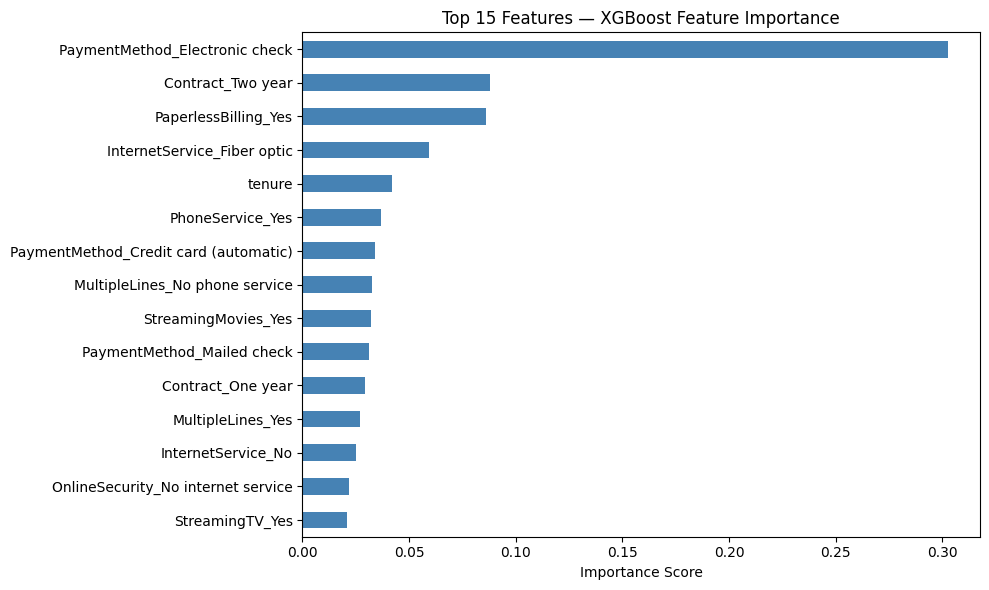


Top 5 most important features:
  PaymentMethod_Electronic check: 0.3025
  Contract_Two year: 0.0880
  PaperlessBilling_Yes: 0.0862
  InternetService_Fiber optic: 0.0593
  tenure: 0.0422


In [20]:
# Top features driving churn predictions
feat_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = feat_importance.nlargest(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Features — XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../docs/xgb_feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 most important features:")
for feat, score in top_features.head(5).items():
    print(f"  {feat}: {score:.4f}")

In [21]:
# Save the model for backend use 
import pickle

with open('../backend/models/churn_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# No re-save for feature_columns.pkl

# Save test set for the /evaluate backend route
import json
test_data = {
    "X_test": X_test.values.tolist(),
    "y_test": y_test.tolist(),
    "feature_columns": X_test.columns.tolist()
}
with open('../backend/models/test_set.json', 'w') as f:
    json.dump(test_data, f)

print("XGBoost model saved to backend/models/churn_model.pkl")
print("Test set saved to backend/models/test_set.json")
print(f"Model expects {len(X_test.columns)} features")

XGBoost model saved to backend/models/churn_model.pkl
Test set saved to backend/models/test_set.json
Model expects 30 features
